# CSE 450 — Module 04 Case Study: WelcomeBike Rental Prediction
### A Neural Network that predicts total bike rentals per hour

**The business problem (for Zhao, William, and Johnny):**
WelcomeBike's Washington DC branch needs to predict the **total number of bikes rented** for every hour of every day. Knowing demand ahead of time lets them position bikes, staff up, and prove to investors the business model works.

**What we're predicting:** `total = casual + registered` for each hour.
This is a **regression** problem (we predict a *number*, not a category), so our neural network ends in a single output neuron.

**The plan, in the order of this notebook:**
1. Load the data
2. Feature engineering — turn raw columns into signals the network can learn from
3. Split into train / validation / test
4. Scale features and target with `MinMaxScaler` (from the reading)
5. Build & train a Keras neural network
6. Evaluate (RMSE, MAE, R²)
7. Predict on the **December holdout** and export the submission CSV

> Run this top to bottom: **Runtime → Run all**.

## 1. Setup & imports
Keras now lives *inside* TensorFlow (`tensorflow.keras`), exactly as the project page warns. `MinMaxScaler` and the metrics come from scikit-learn — we're allowed to mix sklearn preprocessing with a Keras model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Seeds make results repeatable so my teammates see the same numbers you do.
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Load the data
We pull all three files straight from the course GitHub so anyone can just *Run all*.
- **bikes.csv** — training data (has `casual` + `registered`)
- **bikes_december.csv** — the holdout Zhao wants predictions for (no rental counts — that's our job)
- **mini holdout** — a small set we can self-grade against as many times as we want

In [2]:
BASE = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/"
train_raw = pd.read_csv(BASE + "bikes.csv")
december  = pd.read_csv(BASE + "bikes_december.csv")
mini      = pd.read_csv(BASE + "biking_holdout_test_mini.csv")

print("Training rows:", train_raw.shape)
print("December holdout rows:", december.shape)
print("Mini holdout rows:", mini.shape)
train_raw.head()

Training rows: (112475, 12)
December holdout rows: (1465, 10)
Mini holdout rows: (384, 10)


,dteday,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday
0,1/1/2011,0.0,3,13,3.0,3.0,0.7957,0.8,1,1,0,0
1,1/1/2011,1.0,8,30,1.7,1.7,0.8272,0.8,1,1,0,0
2,1/1/2011,2.0,5,26,1.9,1.9,0.8157,1.1,1,1,0,0
3,1/1/2011,3.0,3,9,2.5,2.5,0.7831,0.8,1,1,0,0
4,1/1/2011,4.0,0,1,2.0,2.0,0.8075,1.1,1,1,0,0


## 3. Feature engineering
A neural network only sees numbers, so we turn the raw columns into useful **features**.

**3a. Pull time signals out of the date.** The date string itself is useless to the network, but `year`, `month`, and `weekday` are very predictive (rentals grow year over year, peak in summer, differ on weekends).

**3b. Cyclical encoding for hour / month / weekday.** Here's the key idea: hour 23 (11pm) and hour 0 (midnight) are *adjacent in time*, but the numbers 23 and 0 are far apart. If we feed the raw number, the network thinks midnight and 11pm are opposites. The fix is to place each cyclical value on a circle using **sine and cosine** — then 23 and 0 sit right next to each other. We do the same for month (December→January) and weekday (Sunday→Monday).

We write this as a function so we apply the **exact same transformation** to the holdout — the project explicitly requires that.

In [3]:
def engineer(df):
    df = df.copy()
    df['dteday'] = pd.to_datetime(df['dteday'], format='%m/%d/%Y')

    # 3a. Calendar parts the network can learn from
    df['year']    = df['dteday'].dt.year
    df['month']   = df['dteday'].dt.month
    df['weekday'] = df['dteday'].dt.weekday        # 0 = Monday ... 6 = Sunday
    df['hr']      = df['hr'].astype(int)

    # 3b. Cyclical encoding: map each repeating value onto a circle (sin + cos)
    for col, period in [('hr', 24), ('month', 12), ('weekday', 7)]:
        df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
        df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

train = engineer(train_raw)
train['total'] = train['casual'] + train['registered']   # <- our prediction target
train[['dteday','hr','hr_sin','hr_cos','total']].head()

,dteday,hr,hr_sin,hr_cos,total
0,2011-01-01,0,0.000000,1.000000,16
1,2011-01-01,1,0.258819,0.965926,38
2,2011-01-01,2,0.500000,0.866025,31
3,2011-01-01,3,0.707107,0.707107,12
4,2011-01-01,4,0.866025,0.500000,1


## 4. Choose the features and build the input matrix
We sort every column into how it should be treated:

- **NUMERIC** (`temp_c`, `feels_like_c`, `hum`, `windspeed`, `year`) — continuous numbers we'll MinMax-scale.
- **CYCLIC** — the sin/cos columns we just built (already between -1 and 1).
- **BINARY** (`holiday`, `workingday`) — already 0/1, leave them.
- **ONE-HOT** (`season`, `weathersit`) — these are *categories* (season 1 isn't "less than" season 4), so we split each into its own 0/1 column with `get_dummies`.

`reindex(...)` forces all 8 one-hot columns to always exist — important because the December data might not contain, say, every weather type, and the network needs the same columns it trained on.

In [4]:
NUMERIC = ['temp_c', 'feels_like_c', 'hum', 'windspeed', 'year']
CYCLIC  = ['hr_sin','hr_cos','month_sin','month_cos','weekday_sin','weekday_cos']
BINARY  = ['holiday', 'workingday']
ONEHOT  = ['season', 'weathersit']
ALL_OH  = ['season_1','season_2','season_3','season_4',
           'weathersit_1','weathersit_2','weathersit_3','weathersit_4']

def build_features(df):
    oh = pd.get_dummies(df[ONEHOT].astype(int).astype(str), columns=ONEHOT)
    oh = oh.reindex(columns=ALL_OH, fill_value=False)   # guarantee identical columns everywhere
    base = df[NUMERIC + CYCLIC + BINARY].reset_index(drop=True)
    return pd.concat([base, oh.reset_index(drop=True)], axis=1)

X_all = build_features(train)
y_all = train['total'].values.reshape(-1, 1)
print("Feature matrix shape:", X_all.shape)
X_all.head()

Feature matrix shape: (112475, 21)


,temp_c,feels_like_c,hum,windspeed,year,hr_sin,hr_cos,month_sin,month_cos,weekday_sin,...,holiday,workingday,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,3.0,3.0,0.7957,0.8,2011,0.000000,1.000000,0.5,0.866025,-0.974928,...,0,0,True,False,False,False,True,False,False,False
1,1.7,1.7,0.8272,0.8,2011,0.258819,0.965926,0.5,0.866025,-0.974928,...,0,0,True,False,False,False,True,False,False,False
2,1.9,1.9,0.8157,1.1,2011,0.500000,0.866025,0.5,0.866025,-0.974928,...,0,0,True,False,False,False,True,False,False,False
3,2.5,2.5,0.7831,0.8,2011,0.707107,0.707107,0.5,0.866025,-0.974928,...,0,0,True,False,False,False,True,False,False,False
4,2.0,2.0,0.8075,1.1,2011,0.866025,0.500000,0.5,0.866025,-0.974928,...,0,0,True,False,False,False,True,False,False,False


## 5. Train / validation / test split
We carve the data into three pieces:
- **Train (70%)** — the network learns from this.
- **Validation (15%)** — checked *during* training to catch overfitting and decide when to stop.
- **Test (15%)** — never seen during training; our honest estimate of real-world accuracy.

In [5]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_all, y_all, test_size=0.30, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)
print(f"Train: {X_tr.shape[0]}  |  Validation: {X_val.shape[0]}  |  Test: {X_te.shape[0]}")

Train: 78732  |  Validation: 16871  |  Test: 16872


## 6. Scale with MinMaxScaler
Neural networks train far better when every input is on a similar scale. `temp_c` might run 0–40 while `hum` runs 0–1 — left alone, the big-numbered features dominate. **MinMax scaling** squeezes each numeric feature into the 0–1 range (the reading recommends exactly this).

Two critical rules:
1. **Fit the scaler on the training data only**, then *apply* it to validation/test/holdout. Fitting on test data would leak information.
2. We also scale the **target** (`total`) to 0–1 so the loss values stay small and stable — then we **inverse-transform** the predictions back into real bike counts at the end.

In [6]:
x_scaler = MinMaxScaler().fit(X_tr[NUMERIC])   # learn min/max from TRAIN only
y_scaler = MinMaxScaler().fit(y_tr)

def scale_X(X):
    X = X.copy()
    X[NUMERIC] = x_scaler.transform(X[NUMERIC])
    return X.astype('float32').values

X_tr_s, X_val_s, X_te_s = scale_X(X_tr), scale_X(X_val), scale_X(X_te)
y_tr_s, y_val_s = y_scaler.transform(y_tr), y_scaler.transform(y_val)
print("Scaled. Input width =", X_tr_s.shape[1], "features")

Scaled. Input width = 21 features


## 7. Build the neural network
This is a **Sequential** model — layers stacked front to back.

- **Input layer** — one slot per feature (21 of them).
- **Hidden layers** `Dense(256) → Dense(128) → Dense(64)` — these are the "neurons." Each neuron takes a weighted sum of the previous layer and passes it through an **activation function**. We use **ReLU** (`max(0, x)`), the workhorse from the reading: it's fast and lets the network learn non-linear patterns (like "rentals spike at 8am AND 5pm").
- **Dropout(0.2)** — randomly switches off 20% of neurons each step during training. This is **regularization**: it stops the network from memorizing the training data (overfitting).
- **Output layer** `Dense(1, 'linear')` — a single neuron with **no** activation, because we're predicting one continuous number (the bike count), not a probability or a category.

In [7]:
model = keras.Sequential([
    layers.Input(shape=(X_tr_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1,   activation='linear'),   # regression output
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 46,849 (183.00 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile the model
Compiling tells the network **how to learn**:
- **Loss = MSE (mean squared error)** — the number the network tries to drive down. Squaring punishes big misses harder.
- **Optimizer = Adam** — the algorithm that does **gradient descent**: it nudges every weight a little, in the direction that lowers the loss, over and over. **Backpropagation** is how it figures out which direction. (These are the exact mechanics from the MIT/3Blue1Brown videos.)
- **Metric = MAE (mean absolute error)** — easier for humans to read: "on average we're off by N bikes.\"

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)

## 9. Train
- **epoch** = one full pass through the training data. We allow up to 100.
- **batch_size = 256** = the network updates its weights after every 256 rows (faster and steadier than one row at a time).
- **EarlyStopping** watches the validation loss and **stops automatically** when it stops improving, then restores the best weights. This is our main guard against overfitting and wasted time.

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_val_s, y_val_s),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1,
)
print(f"\nStopped after {len(history.history['loss'])} epochs.")

Epoch 1/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0110 - mae: 0.0710 - val_loss: 0.0055 - val_mae: 0.0483
Epoch 2/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0058 - mae: 0.0507 - val_loss: 0.0045 - val_mae: 0.0452
Epoch 3/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045 - mae: 0.0444 - val_loss: 0.0036 - val_mae: 0.0396
Epoch 4/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0039 - mae: 0.0410 - val_loss: 0.0033 - val_mae: 0.0369
Epoch 5/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0037 - mae: 0.0392 - val_loss: 0.0032 - val_mae: 0.0375
Epoch 6/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035 - mae: 0.0380 - val_loss: 0.0031 - val_mae: 0.0376
Epoch 7/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - mae: 0.0371 - val_loss: 0.0030 - val_mae: 0.0357
Epoch 8/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0364 - val_loss: 0.0029 - val_mae: 0.0361
Epoch 9/100
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/

### Training curves
If the two lines track each other and flatten out, training went well. A big gap (train loss far below validation loss) would signal overfitting.

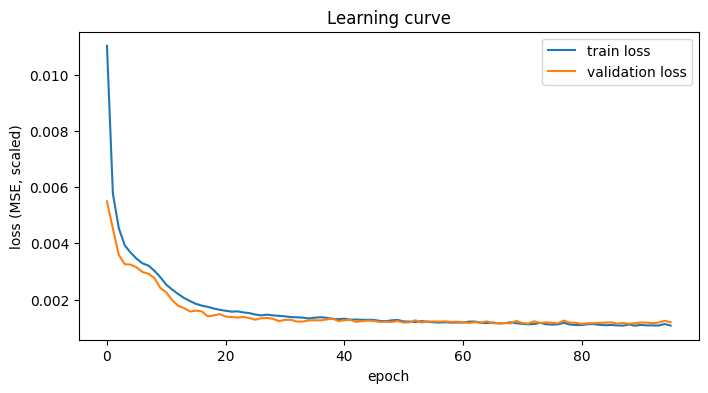

In [10]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch'); plt.ylabel('loss (MSE, scaled)')
plt.title('Learning curve'); plt.legend(); plt.show()

## 10. Evaluate on the untouched test set
We predict on the test set, then **inverse-transform** back to real bike counts (`y_scaler.inverse_transform`). We `clip(0)` because you can't rent negative bikes, and `round()` to whole bikes.

- **RMSE / MAE** — how many bikes off we are on average (lower is better).
- **R²** — fraction of the variation in demand the model explains (1.0 is perfect). This is the metric the class leaderboard sorts on.

In [11]:
def to_counts(scaled_pred):
    return y_scaler.inverse_transform(scaled_pred).clip(0).round()

test_pred = to_counts(model.predict(X_te_s, verbose=0))

print(f"RMSE: {root_mean_squared_error(y_te, test_pred):.1f} bikes")
print(f"MAE : {mean_absolute_error(y_te, test_pred):.1f} bikes")
print(f"R²  : {r2_score(y_te, test_pred):.4f}")

RMSE: 71.7 bikes
MAE : 47.9 bikes
R²  : 0.9571


### Predicted vs. actual
Points hugging the red line = accurate predictions. This is the same chart the grading notebook produces.

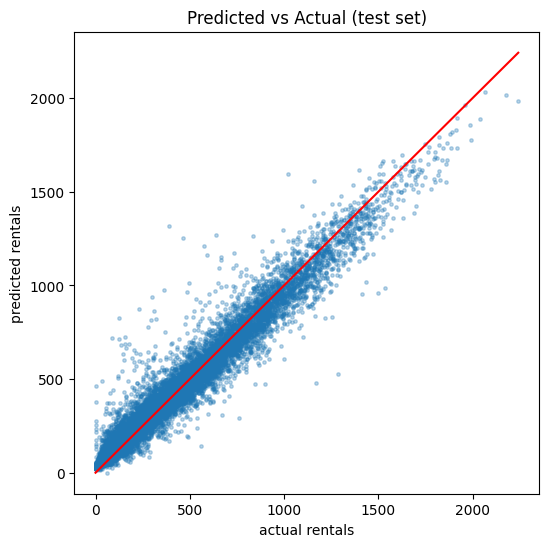

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_te, test_pred, s=6, alpha=0.3)
lims = [0, float(y_te.max())]
plt.plot(lims, lims, 'r')
plt.xlabel('actual rentals'); plt.ylabel('predicted rentals')
plt.title('Predicted vs Actual (test set)'); plt.show()

## 11. Self-grade on the MINI holdout (optional but smart)
We can score against the mini holdout as many times as we like to confirm our CSV format and sanity-check accuracy. Same `engineer` + `build_features` + `scale_X` pipeline — **never sort, shuffle, or drop holdout rows.**

In [13]:
mini_X = scale_X(build_features(engineer(mini)))
mini_pred = to_counts(model.predict(mini_X, verbose=0)).astype(int).flatten()
pd.DataFrame({'predictions': mini_pred}).to_csv('mini-predictions.csv', index=False)
print("Mini predictions saved:", len(mini_pred), "rows (should be 384)")

Mini predictions saved: 384 rows (should be 384)


## 12. December holdout → the real submission
This is what Zhao asked for: the total predicted rentals for every hour in **bikes_december.csv**. Identical pipeline.

**Output format the grader requires:** one column, header exactly `predictions`, one row per holdout row, in the original order.
Rename the file to your team's name, e.g. `team8-module4-predictions.csv`, before uploading to the grading notebook.

In [14]:
december_X = scale_X(build_features(engineer(december)))
december_pred = to_counts(model.predict(december_X, verbose=0)).astype(int).flatten()

submission = pd.DataFrame({'predictions': december_pred})
submission.to_csv('team-module4-predictions.csv', index=False)   # <-- rename "team" to your team number
print("December predictions saved:", len(december_pred), "rows (should be 1465)")
submission.head()

December predictions saved: 1465 rows (should be 1465)


,predictions
0,82
1,46
2,40
3,39
4,44


## 13. What to hand the stakeholders
- **The CSV** (`team#-module4-predictions.csv`) — the per-hour December predictions.
- **Executive summary** — translate the metrics into business language: "Our model explains ~96% of the variation in hourly demand and is typically within ~48 bikes of actual. Demand is driven most by hour of day, temperature, working-day status, and season." That directly answers Zhao (predict demand) and William (which factors drive revenue).

**Ideas to push accuracy further if you have time:** grid-search the layer sizes / learning rate (Johnny's hint), add interaction features, or try an ensemble of a few networks and average them.